# Meta-learning: rehearse on new classes, then few-shot learn OTHER new classes

The right test for meta-learning: how fast can a model learn brand-NEW classes from only a few
clips? We use THREE disjoint groups of classes:

- **OLD (10)** - SELECTED_CLASSES, the classes the ResNet50 already knows. Used only to measure
  FORGETTING (did adapting to new classes wreck the old ones).
- **REHEARSAL (5)** - TASK_1. MAML meta-trains here: many N-way K-shot episodes of classes the
  model has NOT seen, so it learns the SKILL of adapting fast to something new.
- **EXAM (5)** - TASK_2, a DIFFERENT set of unseen classes. Both arms few-shot adapt to these and
  are graded. MAML never rehearsed on TASK_2, so this is a fair test of the learned skill.

- **No meta** - take the trained model and few-shot fine-tune it straight to the EXAM classes.
- **MAML** - first rehearse on TASK_1, then few-shot adapt to the EXAM classes.

Both start from the same model and use the same few shots; only MAML rehearses first. We report
EXAM-class accuracy (did it learn them) and OLD-class retention (did it forget).


## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [ ]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [01:02<00:00, 113MB/s] 

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.5 MB/s eta 0:00:00a 0:00:01


In [5]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Setup**

In [6]:
OLD_N      = len(cfg.SELECTED_CLASSES)   # 10 known classes the ResNet50 was trained on (retention only)
N_WAY      = 5                           # classes per episode: TASK_1 has 5 (rehearse), TASK_2 has 5 (exam)
K_SHOT     = 5                           # shots per class - the small-sample limit; try 1 for a bigger gap
K_QUERY    = 5
EVAL_DRAWS = 5                           # exam episodes to average (each also checks old-class retention)

META_EPOCHS   = 5                        # rehearsal (MAML arm only) - episodes drawn from TASK_1
META_EPISODES = 30
INNER_LR      = 0.01
INNER_STEPS   = 5
META_LR       = 1e-4                      # gentle: a large meta-lr degrades the strong ResNet50 init
print(f"{N_WAY}-way {K_SHOT}-shot | rehearse on TASK_1 (5 new) -> exam on TASK_2 (5 other new)")


5-way 5-shot | new classes = TASK_1 + TASK_2 (10 unseen)


## **Preprocess data**

Three disjoint groups: the OLD 10 (retention check only), TASK_1 (rehearsal - MAML meta-trains
here), and TASK_2 (the exam - both arms few-shot adapt here). TASK_2 is truly held out: it is
never rehearsed on.


In [7]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [8]:
# KNOWN 10  (max_samples caps TRAIN clips/class via cfg.MAX_SAMPLES; None = full data)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [9]:
# NEW (TASK 1)
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [10]:
# NEW (TASK 2)
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [11]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx = {c: i for i, c in enumerate(ALL_CLASSES_LIST)}
print(f"{OLD_N} known + {len(cfg.TASK_1) + len(cfg.TASK_2)} new classes")

10 known + 10 new classes


## **Create Loaders**

An old-class test loader (for the retention check) plus two RAM pools: TASK_1 for the rehearsal
episodes (MAML only), and TASK_2 for the exam episodes (both arms).


In [12]:
base_train  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "train"), class_to_idx=class_to_idx)
base_test   = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
old_test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

In [13]:
pool_reh_clips,  pool_reh_labels  = build_pool([task1_train], per_class=20)   # TASK_1 -> rehearsal (meta-train)
pool_exam_clips, pool_exam_labels = build_pool([task2_train], per_class=20)   # TASK_2 -> exam (meta-test)
reh_ids  = sorted(set(pool_reh_labels.tolist()))
exam_ids = sorted(set(pool_exam_labels.tolist()))
print(f"rehearsal {tuple(pool_reh_clips.shape)} classes {len(reh_ids)} | exam {tuple(pool_exam_clips.shape)} classes {len(exam_ids)}")


old pool (200, 16, 3, 224, 224) classes 10 | new pool (200, 16, 3, 224, 224) classes 10


## **Load the ResNet50 (knows the 10 old classes)**

The stage-2 ResNet50 (~93% on the base 10). We keep its trained old-class head aside to measure
retention later. (Run backbone_transfer first so the checkpoint exists in Drive.)

In [14]:
set_seed(cfg.SEED)
base_model = ResNet50LSTM(num_classes=OLD_N).to(device)
base_model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
old_head = copy.deepcopy(base_model.fc)     # trained 10-way head - used to measure old-class retention
print("loaded ResNet50 (knows the 10 old classes)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s] 


loaded ResNet50 (knows the 10 old classes)


## **Old-class accuracy BEFORE any adaptation (retention reference)**

In [15]:
old_acc_before, _, _ = test_model(base_model, old_test_loader, device)
print(f"OLD-class test accuracy before adapting to anything: {old_acc_before:.4f}")

Test Accuracy: 0.9387
OLD-class test accuracy before adapting to anything: 0.9387


## **Common init**

Give the model a fresh N-way head for the new classes. Both arms copy this exact model, so they
start identical - the only later difference is MAML's meta-training.

In [16]:
init_model = copy.deepcopy(base_model)
init_model.fc = nn.Linear(cfg.HIDDEN_SIZE, N_WAY).to(device)
print(init_model.fc)

Linear(in_features=256, out_features=5, bias=True)


## **No meta: few-shot fine-tune to the EXAM classes (TASK_2)**

Take the trained model and adapt it to K shots of the EXAM classes the normal way. Each draw also
re-checks the old-class accuracy through the adapted backbone (retention).


In [17]:
base_new_acc, base_old_ret = [], []
for d in range(EVAL_DRAWS):
    set_seed(cfg.SEED + d)     # draw d reproducible + identical in the MAML arm
    sx, sy, qx, qy = sample_episode(pool_exam_clips, pool_exam_labels, exam_ids, N_WAY, K_SHOT, K_QUERY, device)
    na, orr = adapt_new_and_retain(copy.deepcopy(init_model), sx, sy, qx, qy,
                                   old_head, old_test_loader, INNER_LR, INNER_STEPS, device)
    base_new_acc.append(na); base_old_ret.append(orr)
    torch.cuda.empty_cache()
print(f"no-meta  EXAM acc {np.mean(base_new_acc):.3f}  |  OLD retention {np.mean(base_old_ret):.3f}")


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


no-meta  NEW acc 0.648  |  OLD retention 0.922


## **MAML: rehearse on TASK_1, then adapt to the EXAM classes (TASK_2)**

Meta-train on N-way K-shot episodes of TASK_1 (novel classes the model must actually learn), so
the init gets good at fast adaptation. Then adapt to TASK_2 exactly like the no-meta arm, from the
same K shots. freeze_backbone keeps the strong ResNet50 features and meta-learns a fast head.


In [18]:
set_seed(cfg.SEED)
maml_model = copy.deepcopy(init_model)
maml_model, hist_maml = meta_train_maml(maml_model, pool_reh_clips, pool_reh_labels, reh_ids,
                                        N_WAY, K_SHOT, K_QUERY, META_EPOCHS, META_EPISODES,
                                        INNER_LR, INNER_STEPS, META_LR, device, freeze_backbone=True)


[maml] epoch 1/5 | meta query acc 1.0000
[maml] epoch 2/5 | meta query acc 1.0000


KeyboardInterrupt: 

In [19]:
maml_new_acc, maml_old_ret = [], []
for d in range(EVAL_DRAWS):
    set_seed(cfg.SEED + d)     # SAME seed per draw -> SAME exam episodes as the no-meta arm
    sx, sy, qx, qy = sample_episode(pool_exam_clips, pool_exam_labels, exam_ids, N_WAY, K_SHOT, K_QUERY, device)
    na, orr = adapt_new_and_retain(copy.deepcopy(maml_model), sx, sy, qx, qy,
                                   old_head, old_test_loader, INNER_LR, INNER_STEPS, device)
    maml_new_acc.append(na); maml_old_ret.append(orr)
    torch.cuda.empty_cache()
print(f"MAML     EXAM acc {np.mean(maml_new_acc):.3f}  |  OLD retention {np.mean(maml_old_ret):.3f}")
print(f"MAML gain on EXAM classes: {np.mean(maml_new_acc) - np.mean(base_new_acc):+.3f}")


MAML     NEW acc 0.632  |  OLD retention 0.931
MAML gain on NEW classes: -0.016


## **Rehearsal history (MAML meta-training on TASK_1)**

If this curve starts near 1.0 the rehearsal is too easy (no learning signal). It should start
LOWER and RISE as the init gets better at adapting to the novel TASK_1 episodes.


In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, META_EPOCHS + 1), hist_maml["query_accs"], marker="s")
plt.xlabel("meta epoch"); plt.ylabel("meta query accuracy"); plt.ylim(0, 1.05)
plt.title("MAML rehearsal progress (episodes from TASK_1) - should RISE, not start at 1.0")
plt.tight_layout(); plt.show()


NameError: name 'hist_maml' is not defined

<Figure size 800x500 with 0 Axes>

## **Compare: learning the EXAM classes vs forgetting OLD**

Left: how well each arm learns the EXAM classes (TASK_2) from K shots (higher = better, MAML
should win). Right: old-class accuracy - 'before' vs each arm after adapting (a drop = forgetting).


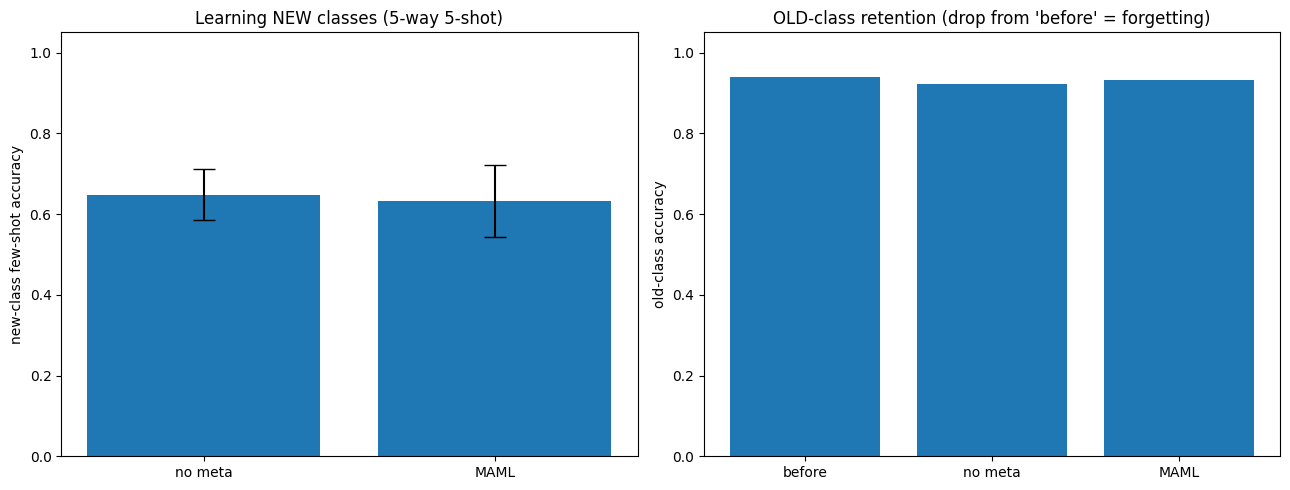

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(["no meta", "MAML"], [np.mean(base_new_acc), np.mean(maml_new_acc)],
        yerr=[np.std(base_new_acc), np.std(maml_new_acc)], capsize=8)
ax1.set_ylim(0, 1.05); ax1.set_ylabel("exam-class few-shot accuracy")
ax1.set_title(f"Learning EXAM classes / TASK_2 ({N_WAY}-way {K_SHOT}-shot)")
ax2.bar(["before", "no meta", "MAML"], [old_acc_before, np.mean(base_old_ret), np.mean(maml_old_ret)])
ax2.set_ylim(0, 1.05); ax2.set_ylabel("old-class accuracy")
ax2.set_title("OLD-class retention (drop from 'before' = forgetting)")
plt.tight_layout(); plt.show()


In [22]:
print(f"{'method':<10}{'EXAM acc':>10}{'OLD retention':>15}{'forgetting':>12}")
print(f"{'no meta':<10}{np.mean(base_new_acc):>10.3f}{np.mean(base_old_ret):>15.3f}{old_acc_before - np.mean(base_old_ret):>12.3f}")
print(f"{'MAML':<10}{np.mean(maml_new_acc):>10.3f}{np.mean(maml_old_ret):>15.3f}{old_acc_before - np.mean(maml_old_ret):>12.3f}")


method       NEW acc  OLD retention  forgetting
no meta        0.648          0.922       0.017
MAML           0.632          0.931       0.008


## **Save**

In [ ]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"n_way": N_WAY, "k_shot": K_SHOT, "eval_draws": EVAL_DRAWS,
           "old_acc_before": old_acc_before,
           "no_meta_new": float(np.mean(base_new_acc)), "no_meta_old_ret": float(np.mean(base_old_ret)),
           "maml_new": float(np.mean(maml_new_acc)),   "maml_old_ret": float(np.mean(maml_old_ret)),
           "maml_curve": hist_maml["query_accs"]}
with open(f"{cfg.RESULTS_DIR}/stage5_meta_fewshot.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage5_meta_fewshot.json")